# Entry the market distribution - Analytics

### Import Library

In [1]:
import pandas as pd
import numpy as np
import pandas_ta as ta
from utils import load_analytics_dataset, show_3_distribution_charts, show_3_sns_charts

import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['figure.dpi'] = 120
import warnings
warnings.filterwarnings('ignore')

### Load Price Data

In [2]:
%%time
dataset = load_analytics_dataset()

CPU times: user 1e+03 ms, sys: 44.9 ms, total: 1.04 s
Wall time: 1.04 s


In [3]:
# data = dataset[dataset.index > '2020-11-01 00:00:00'].copy()
data = dataset.copy()

In [6]:
data

,Open,High,Low,Close,Volume,hour,minute,day_of_month,month,year,...,lower_wick_group,vol_high_pattern,ibs_volume_pattern,volume_avg_group,high_rsi_pattern,high_ub_pattern,low_lb_pattern,couple_cs_signal,ema_cross_signal,allow_entry
Date,,,,,,,,,,,,,,,,,,,,,
2018-08-20 09:05:00,945.8,946.1,945.5,946.1,877,9,5,20,8,2018,...,Longer,VolDown_HighDown,VolDown_IBSUp,VolBelowAvg,HighDown_RSIUp,HighBelowUB,LowAboveLB,NaN,NaN,None
2018-08-20 09:10:00,945.9,946.2,945.7,945.9,604,9,10,20,8,2018,...,Shorter,VolDown_HighUp,VolDown_IBSDown,VolBelowAvg,HighUp_RSIDown,HighBelowUB,LowAboveLB,NaN,NaN,None
2018-08-20 09:15:00,946.0,946.5,946.0,946.1,797,9,15,20,8,2018,...,Shorter,VolUp_HighUp,VolUp_IBSDown,VolBelowAvg,HighUp_RSIUp,HighBelowUB,LowAboveLB,NaN,NaN,None
2018-08-20 09:20:00,946.0,947.1,946.0,946.8,1195,9,20,20,8,2018,...,Shorter,VolUp_HighUp,VolUp_IBSUp,VolBelowAvg,HighUp_RSIUp,HighBelowUB,LowAboveLB,NaN,NaN,None
2018-08-20 09:25:00,946.6,947.0,946.1,946.7,915,9,25,20,8,2018,...,Longer,VolDown_HighDown,VolDown_IBSDown,VolBelowAvg,HighDown_RSIDown,HighBelowUB,LowAboveLB,NaN,NaN,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-11-04 14:10:00,1890.7,1891.0,1885.5,1887.3,5379,14,10,4,11,2025,...,Shorter,VolDown_HighDown,VolDown_IBSDown,VolBelowAvg,HighDown_RSIDown,HighBelowUB,LowAboveLB,NaN,NaN,Bullish
2025-11-04 14:15:00,1887.2,1899.0,1887.2,1898.5,13871,14,15,4,11,2025,...,Shorter,VolUp_HighUp,VolUp_IBSUp,VolAboveAvg,HighUp_RSIUp,HighAboveUB,LowAboveLB,NaN,NaN,Bullish
2025-11-04 14:20:00,1898.2,1907.7,1897.0,1904.2,16090,14,20,4,11,2025,...,Longer,VolUp_HighUp,VolUp_IBSDown,VolAboveAvg,HighUp_RSIUp,HighAboveUB,LowAboveLB,NaN,NaN,Sideway


In [7]:
data.columns

Index(['Open', 'High', 'Low', 'Close', 'Volume', 'hour', 'minute',
       'day_of_month', 'month', 'year', 'day_of_week', 'time_int',
       'session_progress', 'day_high', 'day_low', 'day_close', 'day_open',
       'day_volume', 'day_pivot', 'prev_day_close', 'prev_day_open',
       'prev_day_high', 'prev_day_low', 'prev_day_volume', 'prev_day_pivot',
       'body', 'height', 'upwick', 'lowwick', 'upwick_rate', 'lowwick_rate',
       'body_rate', 'clv', 'cbr', 'vbr', 'ibs', 'wick_imbalance',
       'upwick_ratio', 'color', 'ema_fast', 'ema_slow', 'rsi', 'rsi_slope',
       'tsi', 'roc_close', 'close_zscore', 'efficiency_ratio', 'macd',
       'macd_hist', 'macd_signal', 'ppo', 'ppo_hist', 'ppo_signal',
       'ulcer_index', 'cmo', 'roc_skew', 'roc_kurt', 'mb', 'std', 'ub', 'lb',
       'volume_avg', 'volume_zscore', 'close_lag1', 'open_lag1', 'high_lag1',
       'low_lag1', 'volume_lag1', 'body_lag1', 'upwick_lag1', 'lowwick_lag1',
       'ibs_lag1', 'rsi_lag1', 'ema_fast_lag1', 'ema_

In [8]:
data['allow_entry'] = data['allow_entry'].fillna('NaN')

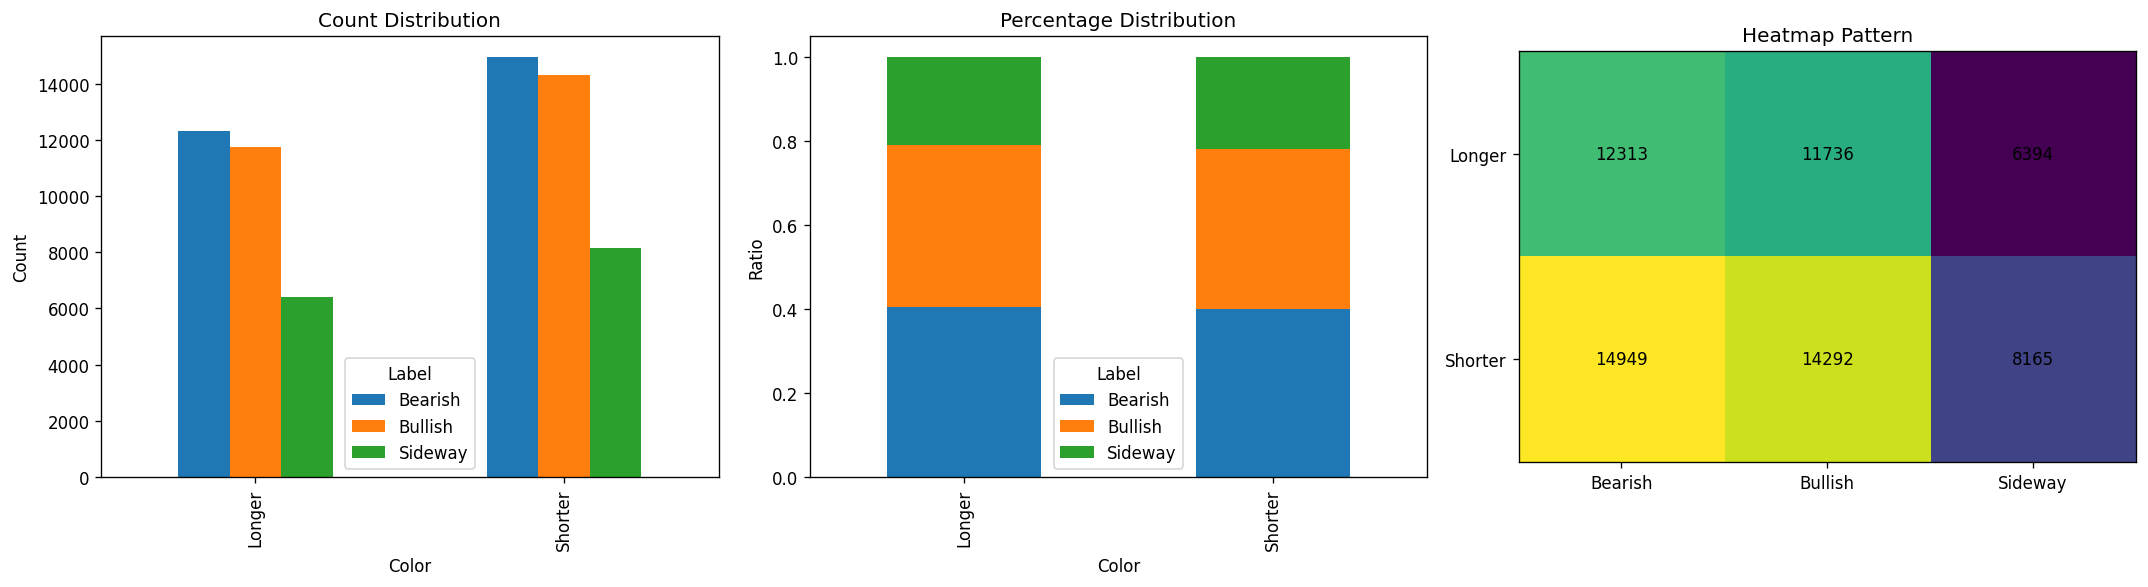

In [24]:
show_3_distribution_charts(data['lower_wick_group'], data['allow_entry'])

## Tỉ lệ % có thể vào lệnh

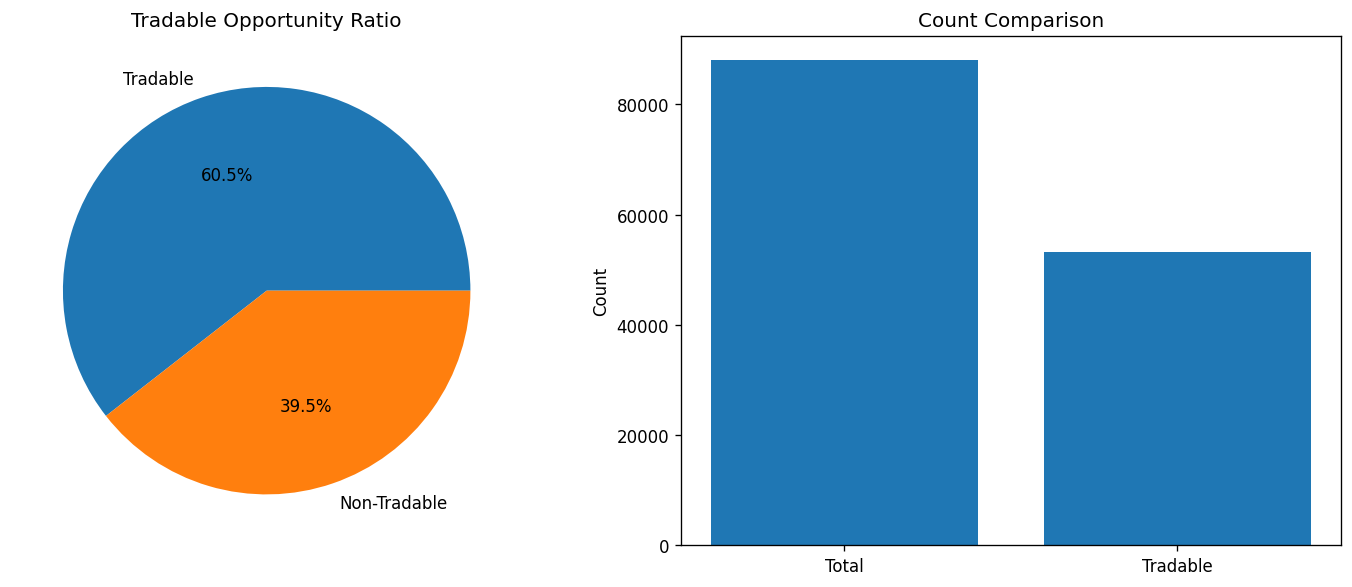

In [12]:
total_time = len(data)
tradable_time = len(data[(data.allow_entry=='Bullish') | (data.allow_entry=='Bearish')])
non_tradable_time = total_time - tradable_time

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1. Pie chart (tỷ lệ)
axes[0].pie(
    [tradable_time, non_tradable_time],
    labels=['Tradable', 'Non-Tradable'],
    autopct='%1.1f%%'
)
axes[0].set_title('Tradable Opportunity Ratio')

# 2. Bar chart (số lượng)
axes[1].bar(
    ['Total', 'Tradable'],
    [total_time, tradable_time]
)
axes[1].set_title('Count Comparison')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

# Analytics

In [16]:
from scipy.stats import chi2_contingency


In [17]:
ct = pd.crosstab(data['hour'], data['allow_entry'])
chi2, p, _, _ = chi2_contingency(ct)
print(p)

0.0


In [10]:
data.ema_cross_signal.unique()

<StringArray>
[nan, 'Bullish', 'Bearish']
Length: 3, dtype: str

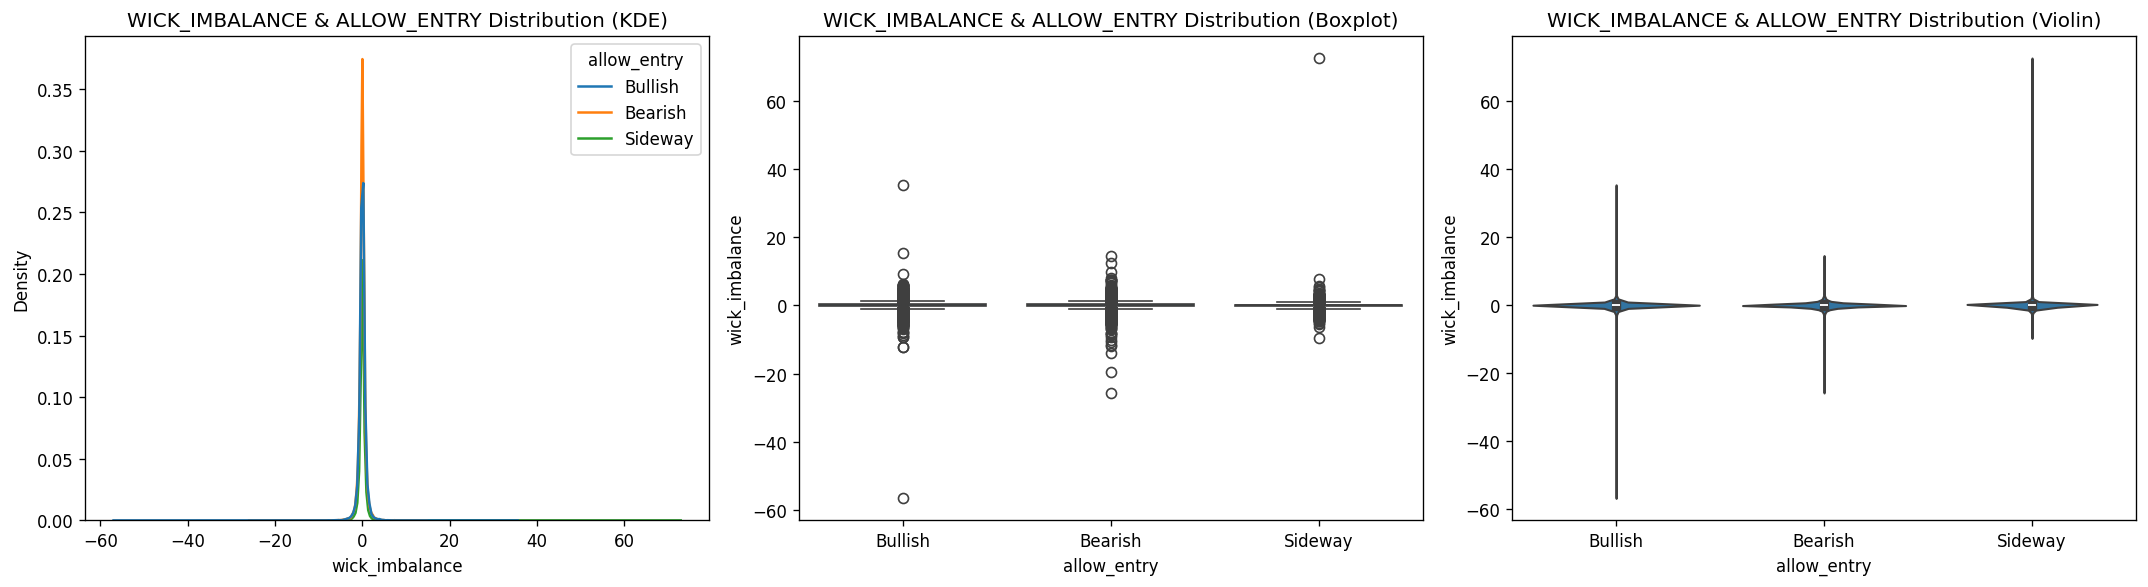

In [12]:
show_3_sns_charts(data, 'wick_imbalance', 'allow_entry')

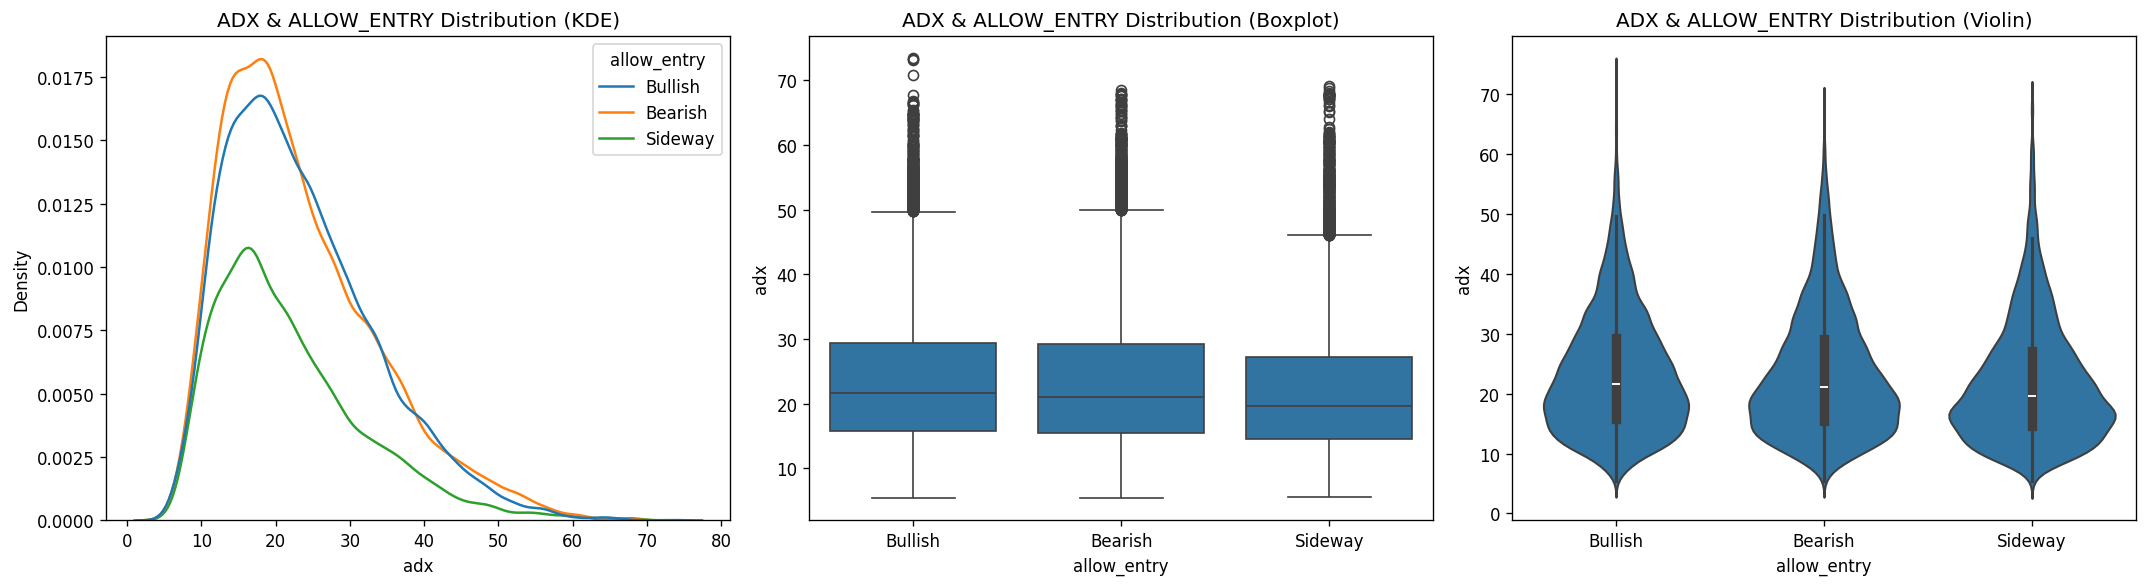

In [6]:
show_3_sns_charts(data, 'adx', 'allow_entry')

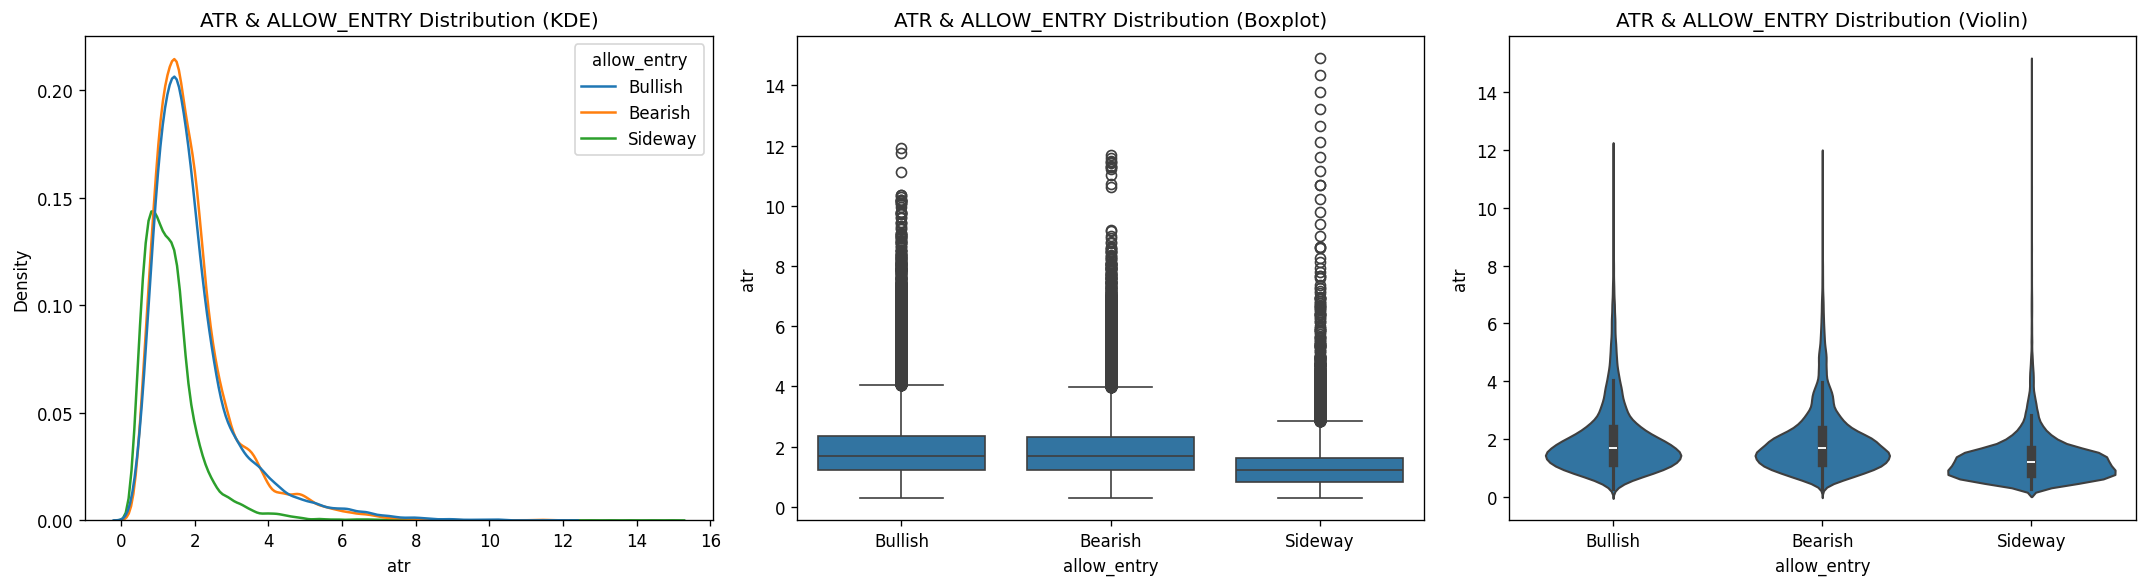

In [5]:
show_3_sns_charts(data, 'atr', 'allow_entry')

In [4]:
dfx = data[data.ema_cross_signal.notna()]

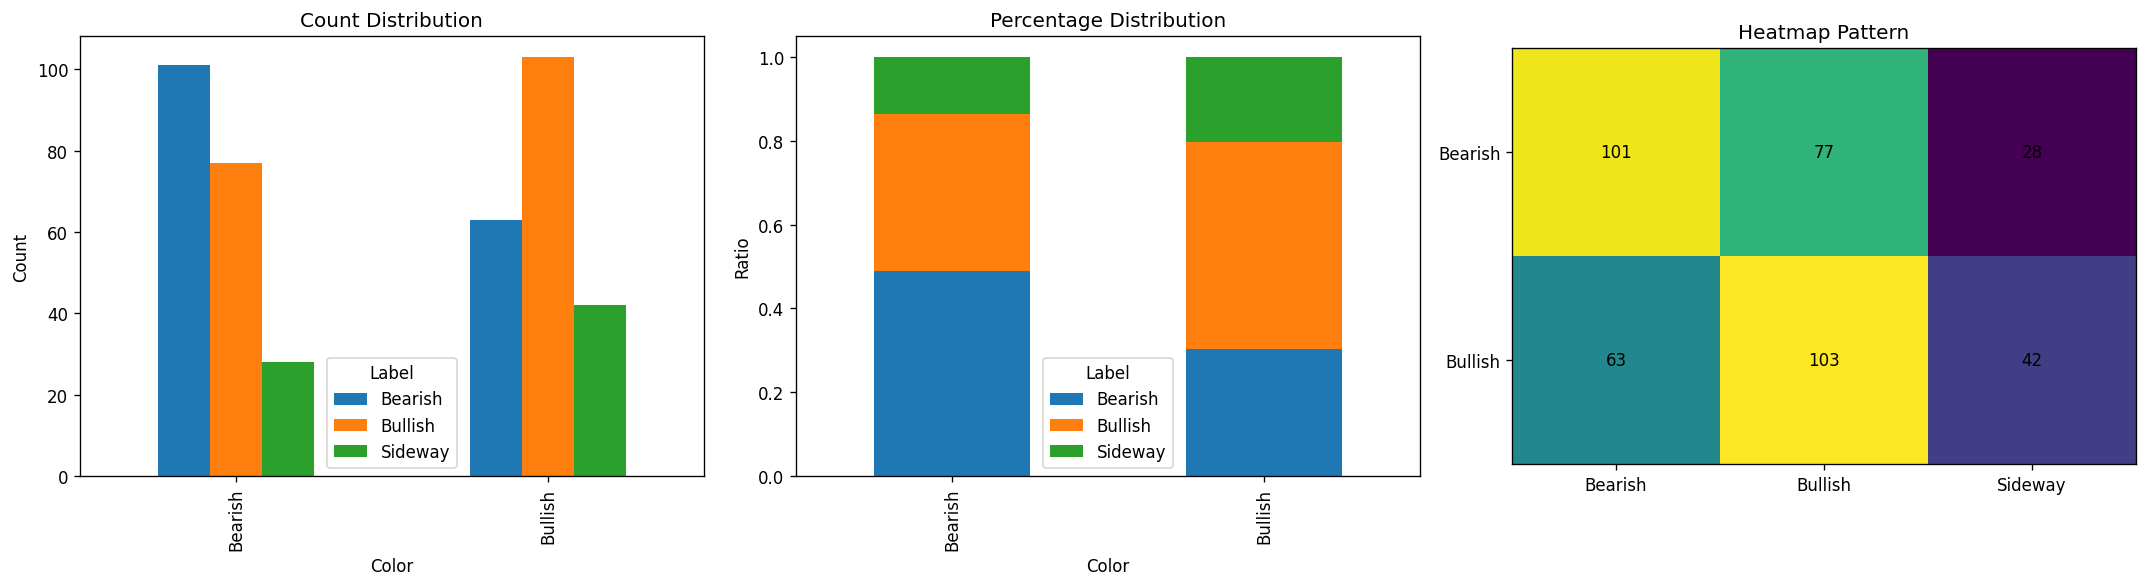

In [5]:
show_3_distribution_chart(dfx['ema_cross_signal'], dfx['allow_entry'])

### 3. MQH giữa màu sắc nến và Allow Entry

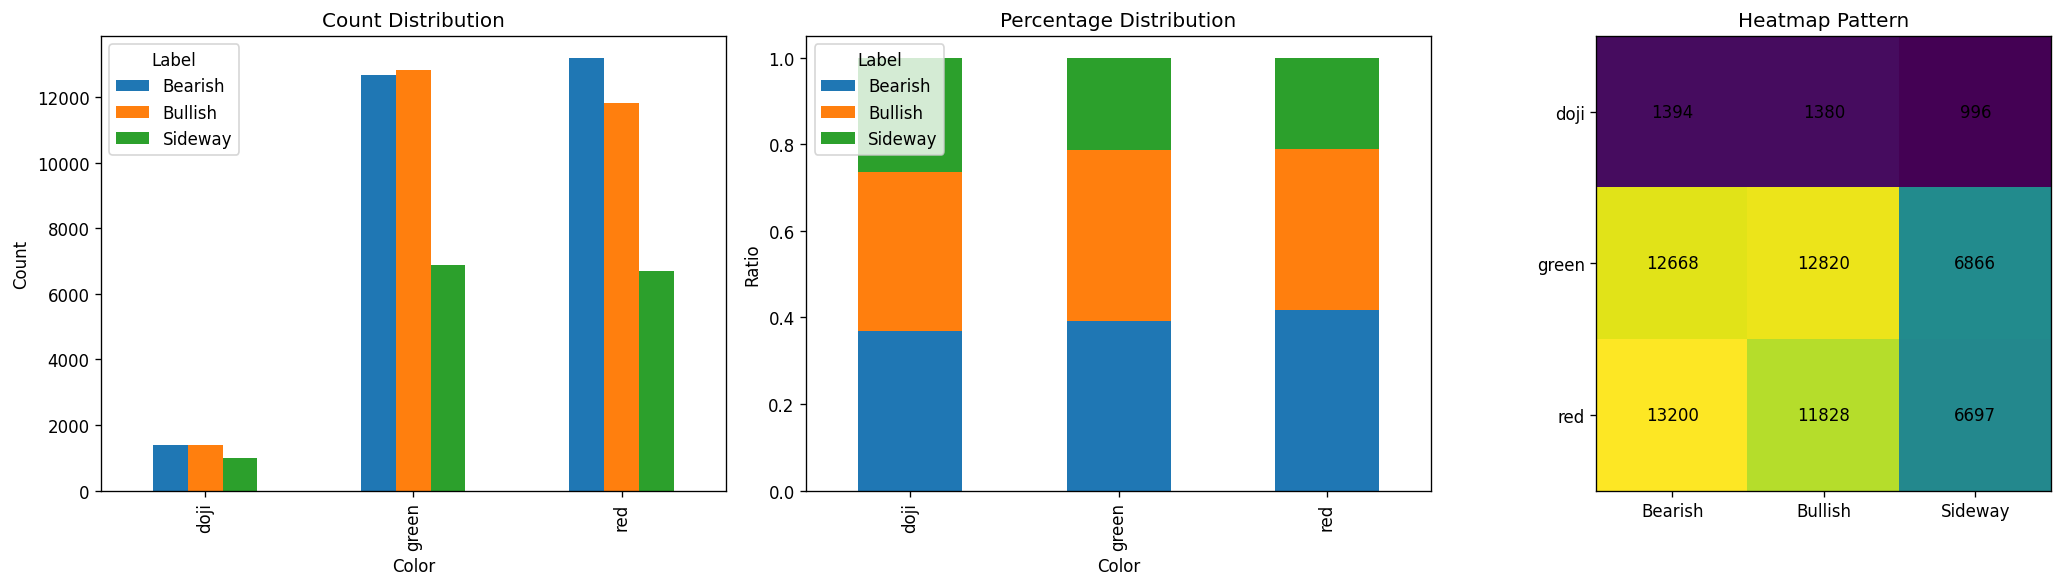

In [6]:
show_3_distribution_chart(data['color'], data['allow_entry'])

## 2. MQH giữa RSI và Allow Entry

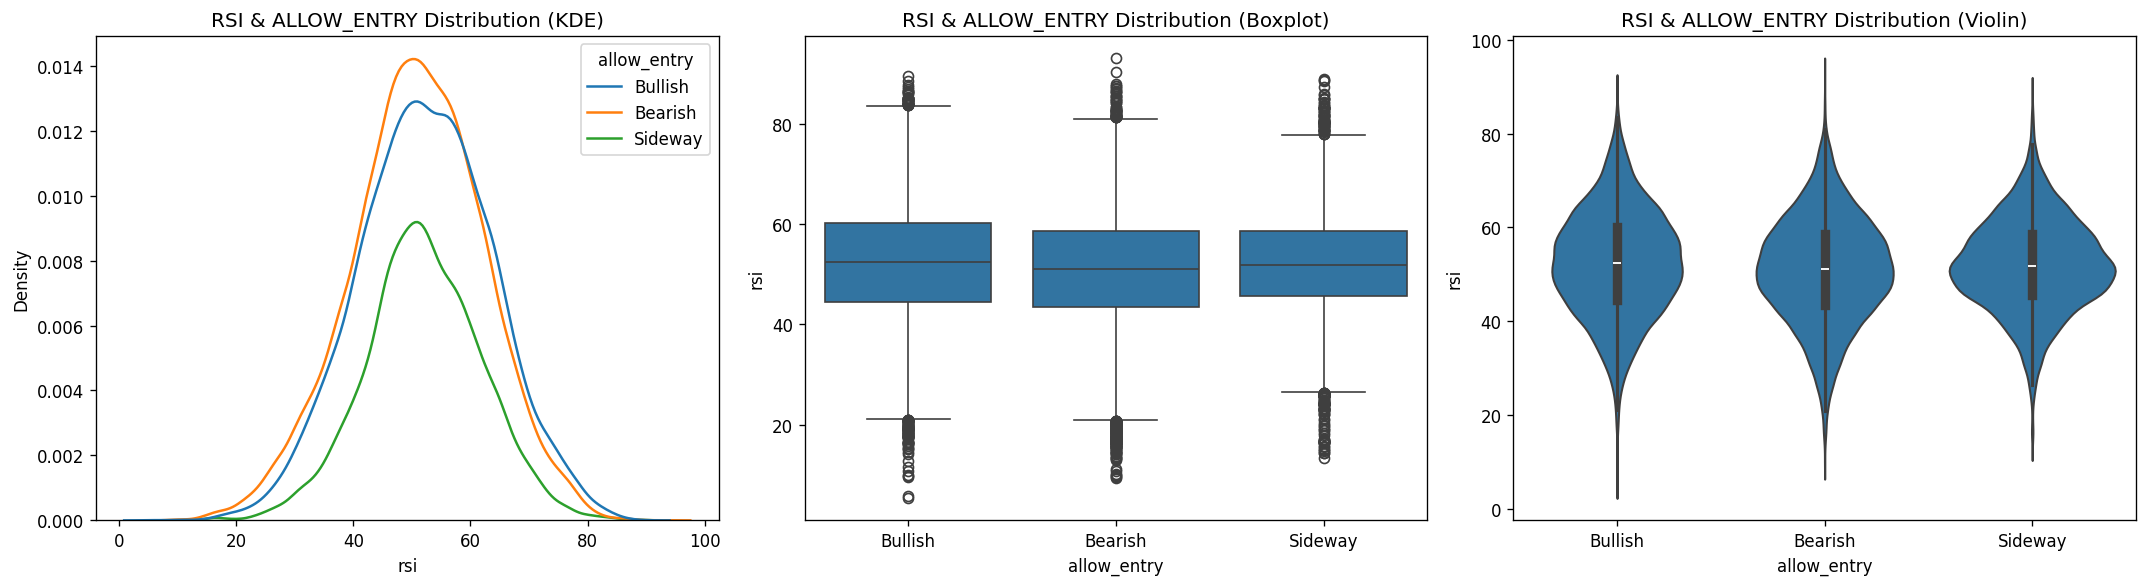

In [4]:
show_3_sns_charts(data, 'rsi', 'allow_entry')

## 1. MQH giữa Hour và Allow Entry

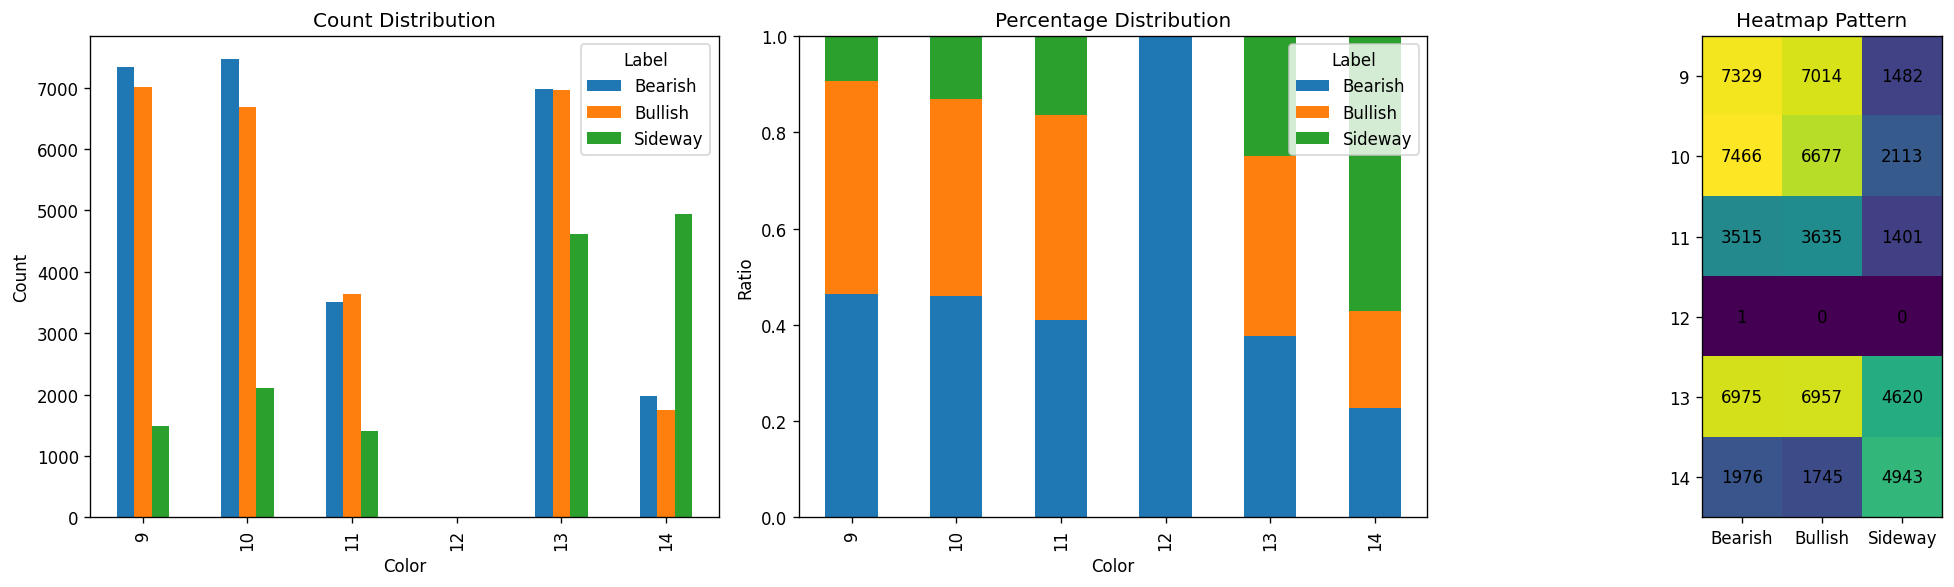

In [9]:
show_3_distribution_chart(data['hour'], data['allow_entry'])